## Failure Classification in Solar Inverters

---

<a id="section1"></a>
# <font color="#004D7F"> 1. Introduction</font>

A PV plant is often composed of a large number of solar inverters. Monitoring them is crucial for the business. Therefore, many renewable energy companies invest significant time in classifying failure types in order to control and prevent future energy losses and, consequently, financial losses.

A fast way to perform this task is by comparing the nominal power vs. irradiance curve with the actual behavior. Through this comparison, it is possible to identify the type of failure based on the observed trend. However, performing this task every day is very exhausting. That is why an automatic classifier becomes an indispensable tool for PV plants.

Below, we present the training of a classification model. This model has been trained using historical classifications from PV plants with the same inverter model (since they tend to present similar types of failures). The inverter power (kW) and irradiance (W/m²) were considered as inputs, and the historical labeled classification was used as the output.

For this project, we use the Sungrow inverter model.


<a id="section2"></a>
# <font color="#004D7F"> 2. Libraries</font>

In [94]:
# Load libraries
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pickle
from imblearn.combine import SMOTETomek
from collections import Counter
from imblearn.under_sampling import NearMiss
from sklearn.preprocessing import MinMaxScaler
import joblib

import warnings
warnings.filterwarnings('ignore')

<a id="section3"></a>
# <font color="#004D7F"> 3. Dataset</font>

<a id="section31"></a>
## <font color="#004D7F"> 3.1. Reading dataset</font>

In [95]:
dataset = pd.read_excel("../data/Dataset_Solarfarm.xlsx")
dataset.head()

,Power (kW),irradiance corr PYR,Classification
0,2856.0,1250.0,Inverter Overtemperature / Wrong regulation se...
1,2837.0,1205.0,Inverter Overtemperature / Wrong regulation se...
2,2436.0,1221.0,Inverter Overtemperature / Wrong regulation se...
3,2462.0,1129.0,Inverter Overtemperature / Wrong regulation se...
4,2946.0,1220.0,Inverter Overtemperature / Wrong regulation se...


<a id="section32"></a>
## <font color="#004D7F"> 3.2. Processing dataset</font>

In [96]:
dataset.shape

(8959, 3)

In [97]:
dataset.dtypes

Power (kW)             float64
irradiance corr PYR    float64
Classification          object
dtype: object

In [98]:
# Class distribution
dataset.groupby('Classification').size()

Classification
Clouds                                                 4718
Fuses melt                                              674
Grid limitation / Market regulation                    1378
Inverter Overtemperature / Wrong regulation setting    1379
Tracking system failure or inefficiency                 810
dtype: int64

In [99]:
#Validating null values
dataset.isnull().sum()

Power (kW)             0
irradiance corr PYR    0
Classification         0
dtype: int64

In [100]:
#Validating null values
dataset.isna().sum()

Power (kW)             0
irradiance corr PYR    0
Classification         0
dtype: int64

In [101]:
#Defining input and output variables

variables_input = ['Power (kW)','irradiance corr PYR']
variables_output = dataset.drop(columns=variables_input).columns
variables_output


Index(['Classification'], dtype='object')

<a id="section4"></a>
# <font color="#004D7F"> 4. Exploratory Data Analysis (EDA)</font>

In [102]:
#Descriptive Statistic
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Power (kW),8959.0,1782.00,838.58,5.0,1212.05,1887.0,2516.0,3070.0
irradiance corr PYR,8959.0,855.95,357.53,61.0,599.10,939.0,1145.0,1500.0


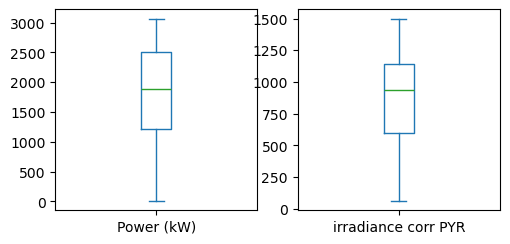

In [103]:
#Verifying variables

df_filter = dataset.iloc[:,:-1].copy()

fig = plt.figure(figsize = (12,12))
ax = fig.gca()
df_filter.plot(ax=ax, kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False)

plt.show()

In [104]:
dataset.head()

,Power (kW),irradiance corr PYR,Classification
0,2856.0,1250.0,Inverter Overtemperature / Wrong regulation se...
1,2837.0,1205.0,Inverter Overtemperature / Wrong regulation se...
2,2436.0,1221.0,Inverter Overtemperature / Wrong regulation se...
3,2462.0,1129.0,Inverter Overtemperature / Wrong regulation se...
4,2946.0,1220.0,Inverter Overtemperature / Wrong regulation se...


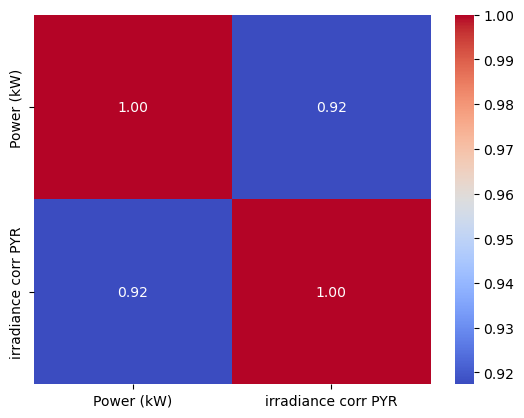

In [105]:
#Correlation

pd.set_option('display.precision', 2)

corr = df_filter.corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

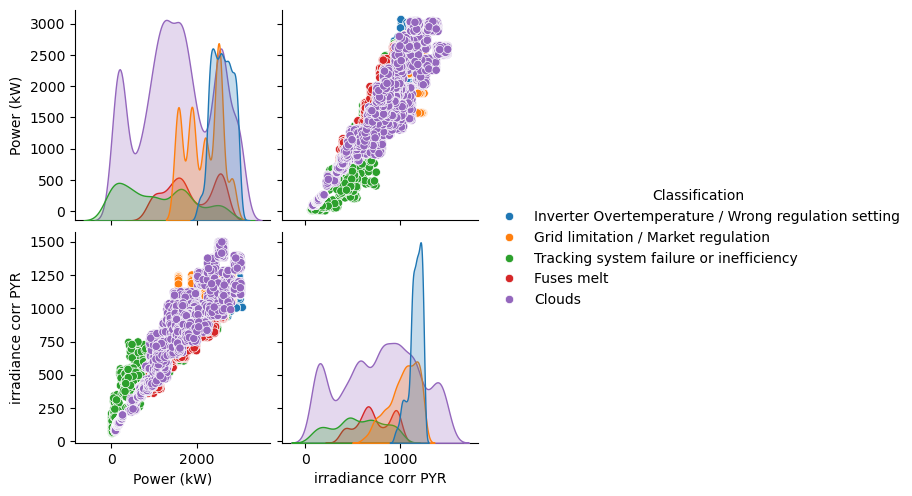

In [106]:
#Verifying classification tendency

sns.pairplot(dataset, hue="Classification")

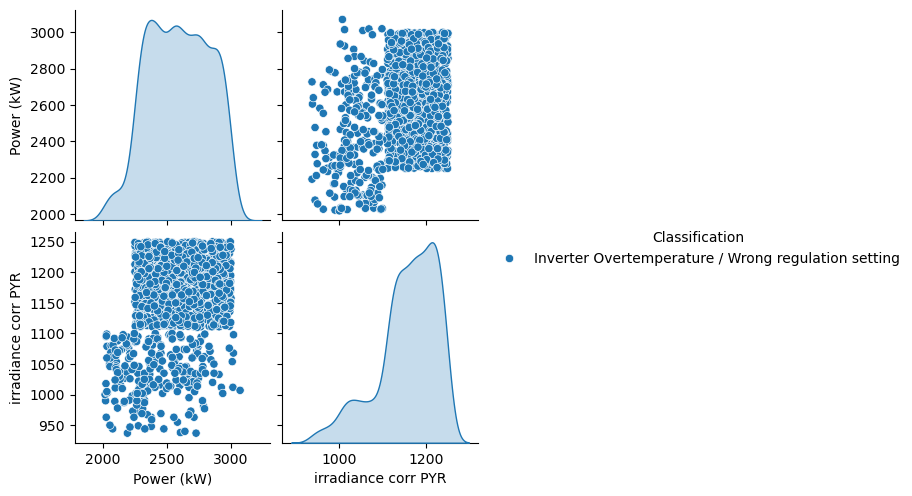

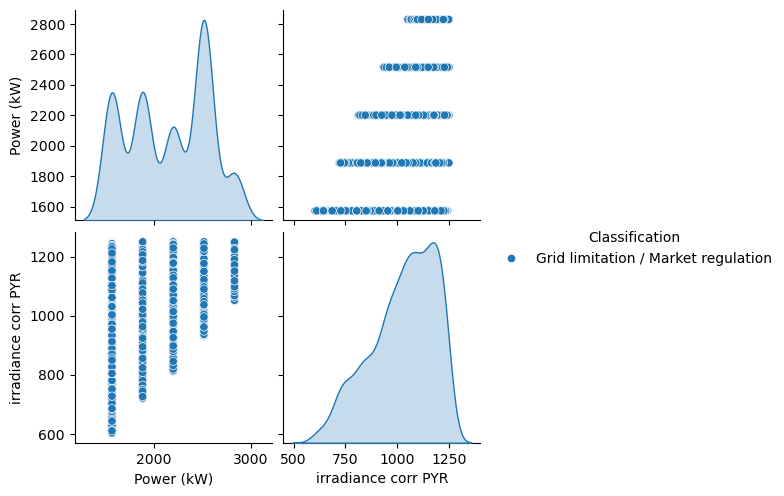

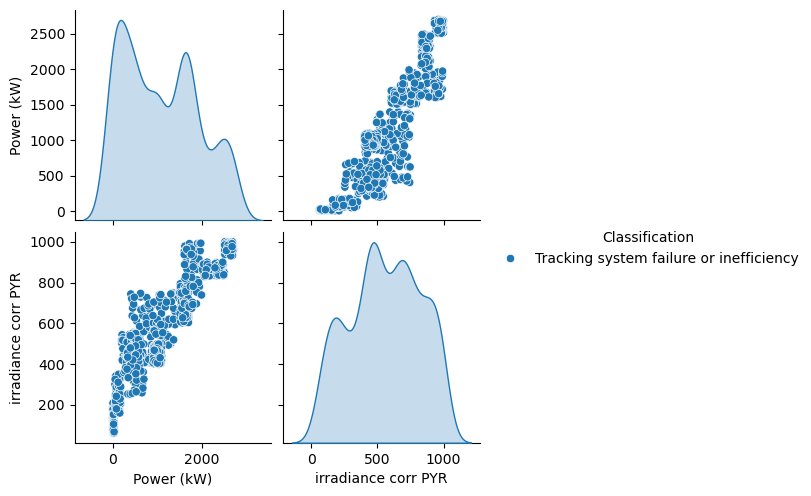

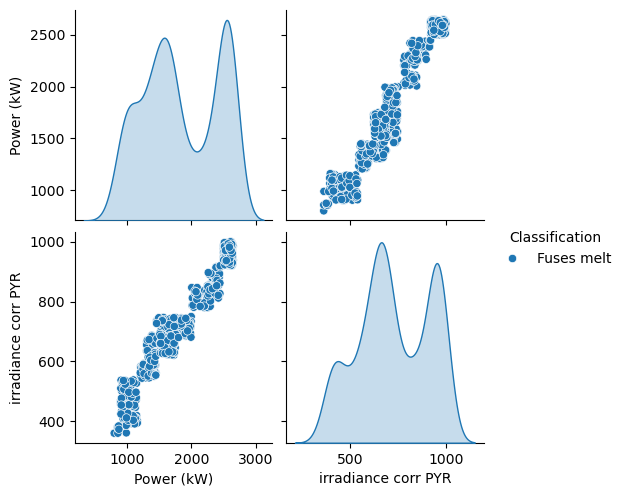

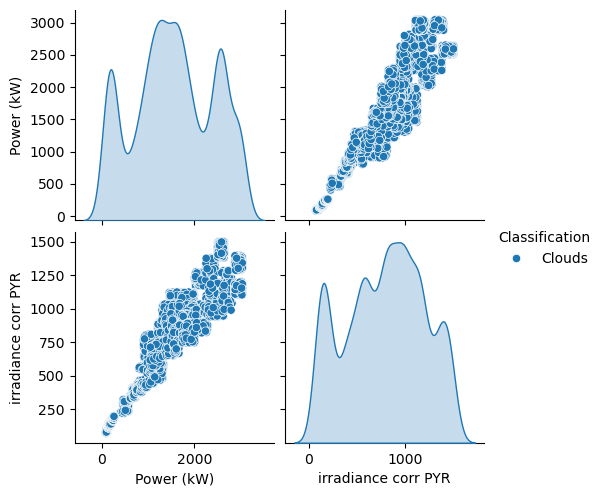

In [107]:
#Verifying classification tendency

for i in dataset["Classification"].unique():
    sns.pairplot(dataset.loc[dataset["Classification"]==i], hue="Classification")

In [108]:
#Class balancing with SMOKETomek
 
os_us = SMOTETomek(sampling_strategy='auto',random_state=42)

X_res, y_res = os_us.fit_resample(dataset.iloc[:,:-1], dataset.iloc[:,-1])

print ("Distribution before resampling {}".format(Counter(dataset.iloc[:,-1])))
print ("Distribution after resampling {}".format(Counter(y_res)))

Distribution before resampling Counter({'Clouds': 4718, 'Inverter Overtemperature / Wrong regulation setting': 1379, 'Grid limitation / Market regulation': 1378, 'Tracking system failure or inefficiency': 810, 'Fuses melt': 674})
Distribution after resampling Counter({'Grid limitation / Market regulation': 4700, 'Inverter Overtemperature / Wrong regulation setting': 4594, 'Fuses melt': 4518, 'Tracking system failure or inefficiency': 4421, 'Clouds': 4353})


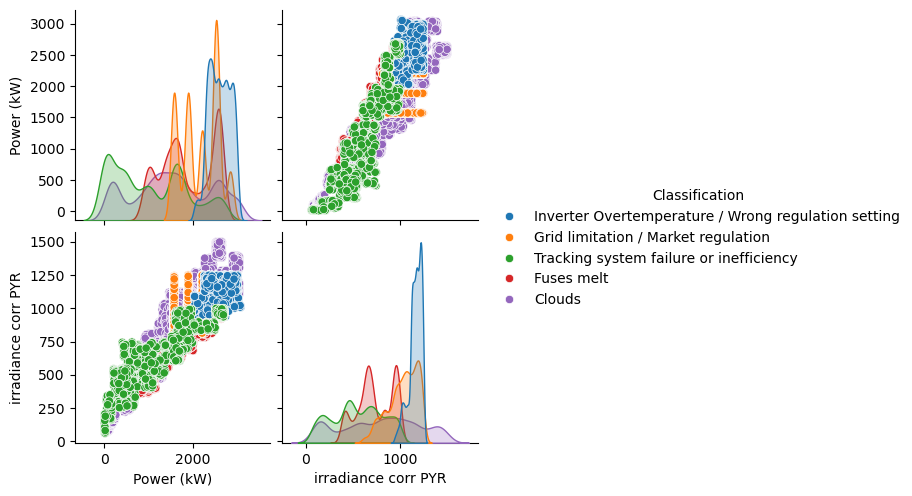

In [109]:
dataset_modified = pd.DataFrame(columns = dataset.columns)

dataset_modified[dataset.columns[-1]] = y_res
dataset_modified[dataset.columns[:-1]] = X_res

sns.pairplot(dataset_modified, hue="Classification")

<a id="section5"></a>
# <font color="#004D7F"> 5. Selecting input variables</font>

In [110]:
X = dataset_modified.iloc[:,:-1].values
Y = dataset_modified.iloc[:,-1].values

X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, 
                                               test_size=0.2, random_state=7, shuffle=True)

<a id="section6"></a>
# <font color="#004D7F"> 6. Selecting model</font>

LoR: 52.65% (1.24%)
LDA: 50.20% (1.49%)
k-NN: 89.71% (0.94%)
CART: 91.82% (0.72%)
NB: 50.08% (0.93%)
SVM: 65.38% (0.89%)
RF: 92.82% (0.49%)


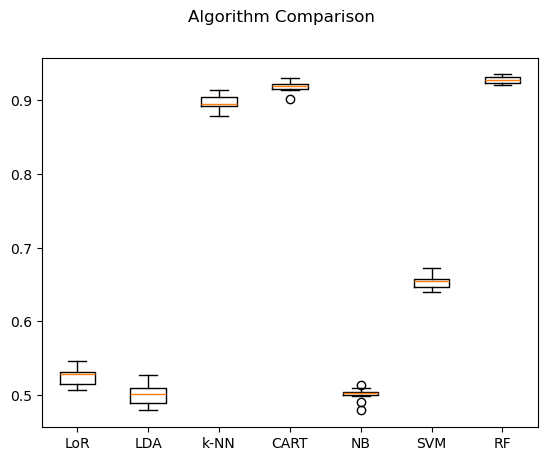

In [111]:
# Spot-Check Algorithms
models = []
models.append(('LoR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('k-NN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier()))
#models.append(('XGB', xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)))

results = []
names = []
seed=3
for name, model in models:
    
    #PIPELINE
    estimators = []
    estimators.append(('standardize',StandardScaler()))
    estimators.append((name,model))
    model_PIPELINE = Pipeline(estimators)

    kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model_PIPELINE, X_train, Y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean()*100.0:,.2f}% ({cv_results.std()*100.0:,.2f}%)")

# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

<a id="section7"></a>
# <font color="#004D7F"> 7. Training and saving model</font>

In [112]:
#GRIDSEARCH to select the best hyperparameters

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier())
])

param_grid = {
    'scaler__with_mean': [True, False],
    'classifier__n_estimators': [10, 50, 100],
    'classifier__max_depth': [None, 10, 20, 50],
}

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)
print("Mejores parámetros:", grid_search.best_params_)
accuracy = grid_search.best_estimator_.score(X_validation, Y_validation)
print("Precisión en el conjunto de prueba:", accuracy)

Mejores parámetros: {'classifier__max_depth': 50, 'classifier__n_estimators': 50, 'scaler__with_mean': False}
Precisión en el conjunto de prueba: 0.9342629482071713


In [113]:
# SELECTING RF DUE TO THE GOOD SCORE

#PIPELINE
estimators = []
estimators.append(('standardize',StandardScaler()))
estimators.append(("Classifier",RandomForestClassifier( n_estimators=50)))
model_PIPELINE = Pipeline(estimators)
    
model_PIPELINE.fit(X_train, Y_train)
predictions = model_PIPELINE.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.936033643204958
[[722  18   5  65  46]
 [ 10 861   0   0  32]
 [  0   1 970   1   0]
 [ 12   2   1 877   1]
 [ 44  51   0   0 799]]
                                                     precision    recall  f1-score   support

                                             Clouds       0.92      0.84      0.88       856
                                         Fuses melt       0.92      0.95      0.94       903
                Grid limitation / Market regulation       0.99      1.00      1.00       972
Inverter Overtemperature / Wrong regulation setting       0.93      0.98      0.96       893
            Tracking system failure or inefficiency       0.91      0.89      0.90       894

                                           accuracy                           0.94      4518
                                          macro avg       0.93      0.93      0.93      4518
                                       weighted avg       0.94      0.94      0.94      4518



In [114]:
# Guardar el pipeline completo
joblib.dump(model_PIPELINE, f"../models/classificator_model.pkl")

['../models/classificator_model.pkl']

<a id="section8"></a>
# <font color="#004D7F"> 8. Using model</font>

In [115]:
# Uploading model
modelo_uploaded = joblib.load(f"../models/classificator_model.pkl")
predictions = modelo_uploaded.predict(X_validation)

In [116]:
predictions

array(['Clouds', 'Clouds', 'Tracking system failure or inefficiency', ...,
       'Clouds', 'Fuses melt', 'Grid limitation / Market regulation'],
      shape=(4518,), dtype=object)

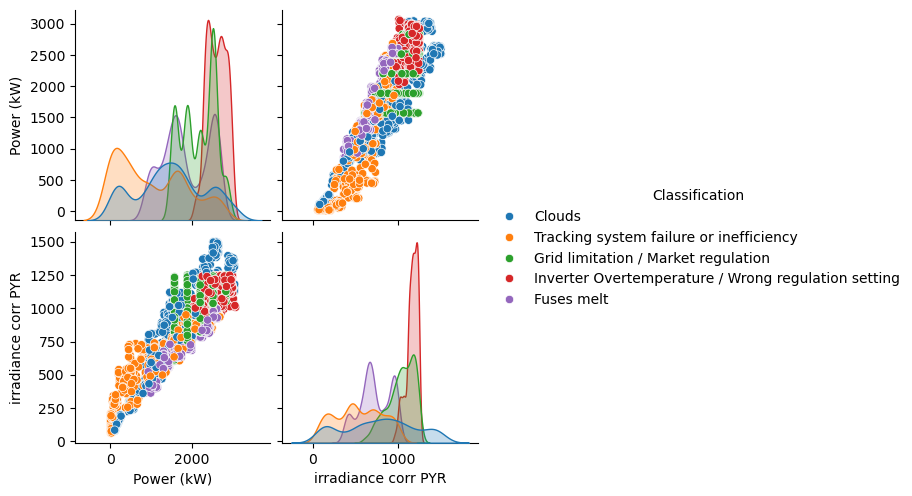

In [117]:
#Classification with model

df_results = pd.DataFrame(columns = dataset.columns)

df_results[df_results.columns[:-1]] = X_validation
df_results[df_results.columns[-1]] = predictions

sns.pairplot(df_results, hue="Classification")